## Назовите проект самостоятельно

Придумайте название для этой тетрадки, которое будет точно отражать суть проекта.

# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

In [1]:
# pip install --upgrade scikit-learn
# pip install phik

In [2]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score, 
    cross_validate,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.feature_selection import (
    VarianceThreshold, 
    RFE,
    mutual_info_classif
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, 
    OneHotEncoder,
    TargetEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    precision_score, 
    recall_score, 
    f1_score,
    brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.dummy import DummyClassifier

from sklearn.frozen import FrozenEstimator
from time import time
import phik
import joblib

In [105]:
# pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [107]:
print("="*60)
print("Версии библиотек")
print("="*60)
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"phik=={phik.__version__}")
print(f"scipy=={scipy.__version__}")
print(f"joblib=={joblib.__version__}")

Версии библиотек
pandas==2.3.3
numpy==1.23.5
scikit-learn==1.6.1
matplotlib==3.10.8
seaborn==0.13.2
phik==0.12.5
scipy==1.10.1
joblib==1.5.3


In [5]:
# задание параметров фигур графиков
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 300)

In [6]:
# фиксация RANDOM_SEED
RANDOM_SEED = 42
print(f"Зафиксированное значение зерна ГПСЧ: {RANDOM_SEED}")

Зафиксированное значение зерна ГПСЧ: 42


In [7]:
# загрузка датасета по ссылке
df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv')

In [8]:
# объем данных
print(f"Размер датасета \nколичество строк: {df.shape[0]} \nколичество столбцов: {df.shape[1]}")

Размер датасета 
количество строк: 50000 
количество столбцов: 34


In [9]:
# вывод первых 5 строк
print("="*60)
print("Первые 5 строк")
print("="*60)
print(df.head())

Первые 5 строк
             id  click      hour    C1  banner_pos   site_id site_domain site_category    app_id app_domain  \
0  1.005263e+19      1  14102100  1005           1  d9750ee7    98572c79      f028772b  ecad2386   7801e8d9   
1  1.010597e+19      0  14102100  1005           0  1fbe01fe    f3845767      28905ebd  ecad2386   7801e8d9   
2  1.012048e+19      0  14102100  1005           0  d9750ee7    98572c79      f028772b  ecad2386   7801e8d9   
3  1.021995e+18      0  14102100  1005           0  85f751fd    c4e18dd6      50e219e0  39cfef32   d9b5648e   
4  1.023455e+19      0  14102100  1005           0  1fbe01fe    f3845767      28905ebd  ecad2386   7801e8d9   

  app_category device_id device_ip device_model  device_type  device_conn_type    C14  C15  C16   C17  C18   C19  \
0     07d7df22  a99f214a  488a9a3e     31025cda            1                 0  17614  320   50  1993    2  1063   
1     07d7df22  a99f214a  75bb1b58     2ee63ff8            1                 0  15701 

In [10]:
# типы данных
print("="*60)
print("Информация о типах столбцов")
print("="*60)
print(df.dtypes)

Информация о типах столбцов
id                  float64
click                 int64
hour                  int64
C1                    int64
banner_pos            int64
site_id              object
site_domain          object
site_category        object
app_id               object
app_domain           object
app_category         object
device_id            object
device_ip            object
device_model         object
device_type           int64
device_conn_type      int64
C14                   int64
C15                   int64
C16                   int64
C17                   int64
C18                   int64
C19                   int64
C20                   int64
C21                   int64
ml_feature_1        float64
ml_feature_2         object
ml_feature_3        float64
ml_feature_4          int64
ml_feature_5        float64
ml_feature_6        float64
ml_feature_7         object
ml_feature_8        float64
ml_feature_9        float64
ml_feature_10       float64
dtype: object


In [11]:
# Проверка успешности загрузки
print("="*60)
if df.shape[0] == 0:
    print("Датасет пуст")
else:
    print("Загрузка данных прошла успешно")

Загрузка данных прошла успешно


## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

#### 2.1 Базовая информация о датасете

In [12]:
# вывод базовой информации
print(f"Число наблюдений в датасете: {df.shape[0]}")
print(f"Число признаков: {df.shape[1] - 1}")

Число наблюдений в датасете: 50000
Число признаков: 33


In [13]:
# числовые и категориальные признаки
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("="*60)
print(f"Числовые признаки ({len(num_cols)}): {num_cols}")
print(f"Категориальные признаки ({len(cat_cols)}): {cat_cols}")

Числовые признаки (23): ['id', 'click', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']
Категориальные признаки (11): ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'ml_feature_2', 'ml_feature_7']


In [14]:
print("="*60)
print("Типы данных")
print(df.dtypes)

Типы данных
id                  float64
click                 int64
hour                  int64
C1                    int64
banner_pos            int64
site_id              object
site_domain          object
site_category        object
app_id               object
app_domain           object
app_category         object
device_id            object
device_ip            object
device_model         object
device_type           int64
device_conn_type      int64
C14                   int64
C15                   int64
C16                   int64
C17                   int64
C18                   int64
C19                   int64
C20                   int64
C21                   int64
ml_feature_1        float64
ml_feature_2         object
ml_feature_3        float64
ml_feature_4          int64
ml_feature_5        float64
ml_feature_6        float64
ml_feature_7         object
ml_feature_8        float64
ml_feature_9        float64
ml_feature_10       float64
dtype: object


#### 2.2 Анализ целевой переменной

In [15]:
# анализ целевой переменной click
click_counts = df['click'].value_counts()
click_percent = df['click'].value_counts(normalize=True) * 100

print("="*60)
print(f"Объем отрицательного класса (0): {click_counts[0]}")
print(f"Доля отрицательного класса в данных: {click_percent[0]:.2f}")
print(f"Объем положительного класса (1): {click_counts[1]}")
print(f"Доля положительного класса в данных: {click_percent[1]:.2f}")
print(f"\nСоотношение классов: {round(click_counts[0]/click_counts[1], 1)} / 1")
print("="*60)

Объем отрицательного класса (0): 41397
Доля отрицательного класса в данных: 82.79
Объем положительного класса (1): 8603
Доля положительного класса в данных: 17.21

Соотношение классов: 4.8 / 1


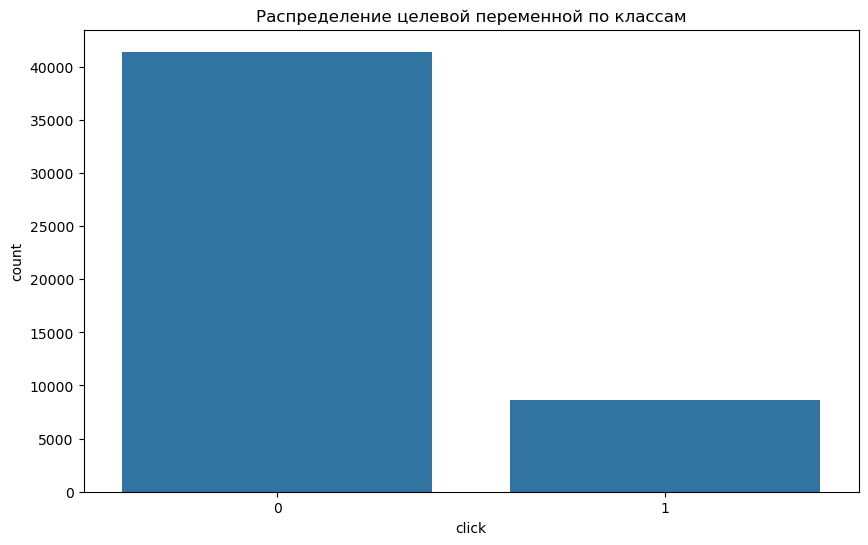

In [16]:
# построение столбчатой диаграммы
sns.countplot(data=df, x='click')
plt.title("Распределение целевой переменной по классам")
plt.show()

---
Процент класса `0` порядка 83%, класса `1` - порядка 17%.  
**Соотношение классов: 4.8:1** — присутствует умеренный дисбаланс в пользу отрицательного класса. Задача с дисбалансом, поэтому используем `PR-AUC` как основную метрику, нечувствительную к дисбалансу.

#### 2.3 Анализ признаков

Одними из первых кандидатов на удаление являются высококардинальные категориальные признаки, для которых число уникальных значений стремится к числу наблюдений в данных: такие признаки не несут предсказательной силы. Определим их количество

In [17]:
print("="*60)
print("Число уникальных значений:")
print("="*60)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cardinal = df[cat_cols].nunique().sort_values(ascending=False)
cardinal

Число уникальных значений:


device_ip        41455
device_id         8580
device_model      2521
site_id           1160
site_domain       1013
app_id             976
app_domain          67
app_category        22
site_category       18
ml_feature_2         5
ml_feature_7         3
dtype: int64

Категориальные столбцы с высокой кардинальностью, где доля уникальных значений превышает 80%, можно в будущем удалить:

In [18]:
cols_to_drop = cardinal[(cardinal / max(cardinal)) > .8].index.to_list()
print("="*60)
print(f"Высококардинальные столбцы для удаления ({len(cols_to_drop)}):")
print("="*60)
print(cols_to_drop)

Высококардинальные столбцы для удаления (1):
['device_ip']


Отметим, что столбец `id`, являющийся уникальным идентификатором каждой строки, не несет предсказательной силы и рекомендован к удалению уже на данном этапе.

In [19]:
# удаление
df.drop(columns='id', inplace=True)
print(f"Размер после удаления: {df.shape[0]} строк и {df.shape[1] - 1} признаков")

Размер после удаления: 50000 строк и 32 признаков


Выведем названия числовых и категориальных признаков с учетом удаления:

In [20]:
# числовые и категориальные признаки
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('click')
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("="*60)
print(f"Числовые признаки ({len(num_cols)}): {num_cols}")
print("="*60)
print(f"Категориальные признаки ({len(cat_cols)}): {cat_cols}")

Числовые признаки (21): ['hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']
Категориальные признаки (11): ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'ml_feature_2', 'ml_feature_7']


---
Таким образом, удалили уникальный идентификатор `id` и рекомендовали столбец `device_ip` с высокой кардинальностью (более 80% значений уникальны) к удалению на будущих этапах проекта.

#### 2.4 Анализ пропущенных значений

In [21]:
# пропуски в столбцах
missing = df.isna().sum()
print("="*60)
print("Процент пропусков в столбцах")
print("="*60)
print(round(missing / len(df) * 100, 2))

Процент пропусков в столбцах
click               0.0
hour                0.0
C1                  0.0
banner_pos          0.0
site_id             0.0
site_domain         0.0
site_category       0.0
app_id              0.0
app_domain          0.0
app_category        0.0
device_id           0.0
device_ip           0.0
device_model        0.0
device_type         0.0
device_conn_type    0.0
C14                 0.0
C15                 0.0
C16                 0.0
C17                 0.0
C18                 0.0
C19                 0.0
C20                 0.0
C21                 0.0
ml_feature_1        0.0
ml_feature_2        0.0
ml_feature_3        0.0
ml_feature_4        0.0
ml_feature_5        0.0
ml_feature_6        0.0
ml_feature_7        0.0
ml_feature_8        0.0
ml_feature_9        0.0
ml_feature_10       0.0
dtype: float64


In [22]:
# выведем столбцы с пропусками
missing[missing > 0].index.to_list()

[]

---
Пропущенных значений нет ни в одном признаке. Данные полностью заполнены — предобработка пропусков не требуется.

#### 2.5 Анализ категориальных признаков

In [23]:
OHE_boundary = 10

for col in cat_cols:
    encoding = None
    if df[col].nunique() > OHE_boundary:
        print(f"Для столбца {col} метод кодирования - Target Encoding\n")
    else:
        print(f"Для столбца {col} метод кодирования - One-hot Encoding\n")

Для столбца site_id метод кодирования - Target Encoding

Для столбца site_domain метод кодирования - Target Encoding

Для столбца site_category метод кодирования - Target Encoding

Для столбца app_id метод кодирования - Target Encoding

Для столбца app_domain метод кодирования - Target Encoding

Для столбца app_category метод кодирования - Target Encoding

Для столбца device_id метод кодирования - Target Encoding

Для столбца device_ip метод кодирования - Target Encoding

Для столбца device_model метод кодирования - Target Encoding

Для столбца ml_feature_2 метод кодирования - One-hot Encoding

Для столбца ml_feature_7 метод кодирования - One-hot Encoding



Для столбцов с высокой кардинальностью (более 10 уникальных значений) применим метод `Target` кодирования во избежание неконтролируемого роста размерности датасета. Для остальных (`ml_feature_2`, `ml_feature_7`) - метод `One-hot` кодирования.

#### 2.6 Анализ выбросов и распределений

In [24]:
# выведем статистики признаков
print("="*60)
print("Статистика числовых признаков:")
print("="*60)
print(df[num_cols].describe())

Статистика числовых признаков:
               hour            C1    banner_pos   device_type  device_conn_type           C14          C15  \
count  5.000000e+04  50000.000000  50000.000000  50000.000000      50000.000000  50000.000000  50000.00000   
mean   1.410256e+07   1004.970060      0.291380      1.018120          0.337160  18826.648680    318.86640   
std    2.967892e+02      1.110202      0.514201      0.538477          0.860057   4983.064178     20.56153   
min    1.410210e+07   1001.000000      0.000000      0.000000          0.000000    375.000000    120.00000   
25%    1.410230e+07   1005.000000      0.000000      1.000000          0.000000  16920.000000    320.00000   
50%    1.410260e+07   1005.000000      0.000000      1.000000          0.000000  20346.000000    320.00000   
75%    1.410281e+07   1005.000000      1.000000      1.000000          0.000000  21916.000000    320.00000   
max    1.410302e+07   1012.000000      7.000000      5.000000          5.000000  24043.00

Для каждого из столбцов определим:  
- количество выбросов, выходящих за отрезок $[Q_1 - 1.5 * IQR; Q_3 + 1.5 * IQR]$;
- процент выбросов относительно полного объема строк в столбце;
- меру скошенности распределения, рассчитанную по коэффициенту асимметрии Фишера (`skew`).

In [25]:
outlier_info = {}
for col in num_cols:
    # квартили
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # межквартильный размах
    IQR = Q3 - Q1
    
    # границы
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # число и процент выбросов
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = n_out / len(df) * 100
    
    # мера скошенности
    skew = df[col].skew()
    
    # объединение в словарь
    outlier_info[col] = {
        'n_outliers': int(n_out),
        'pct_outliers': round(pct_out, 2),
        'skew': round(skew, 3)
    }
    print("="*60)
    print(f"В столбце {col} \nколичество выбросов = {n_out} \nпроцент выбросов = {pct_out:.2f}% \nмера скошенности = {skew:.3f}\n")

В столбце hour 
количество выбросов = 0 
процент выбросов = 0.00% 
мера скошенности = -0.010

В столбце C1 
количество выбросов = 4165 
процент выбросов = 8.33% 
мера скошенности = 1.803

В столбце banner_pos 
количество выбросов = 85 
процент выбросов = 0.17% 
мера скошенности = 3.530

В столбце device_type 
количество выбросов = 3969 
процент выбросов = 7.94% 
мера скошенности = 4.373

В столбце device_conn_type 
количество выбросов = 6979 
процент выбросов = 13.96% 
мера скошенности = 2.331

В столбце C14 
количество выбросов = 4170 
процент выбросов = 8.34% 
мера скошенности = -1.875

В столбце C15 
количество выбросов = 3213 
процент выбросов = 6.43% 
мера скошенности = 15.980

В столбце C16 
количество выбросов = 2713 
процент выбросов = 5.43% 
мера скошенности = 5.548

В столбце C17 
количество выбросов = 4224 
процент выбросов = 8.45% 
мера скошенности = -1.624

В столбце C18 
количество выбросов = 0 
процент выбросов = 0.00% 
мера скошенности = 0.047

В столбце C19 
количество

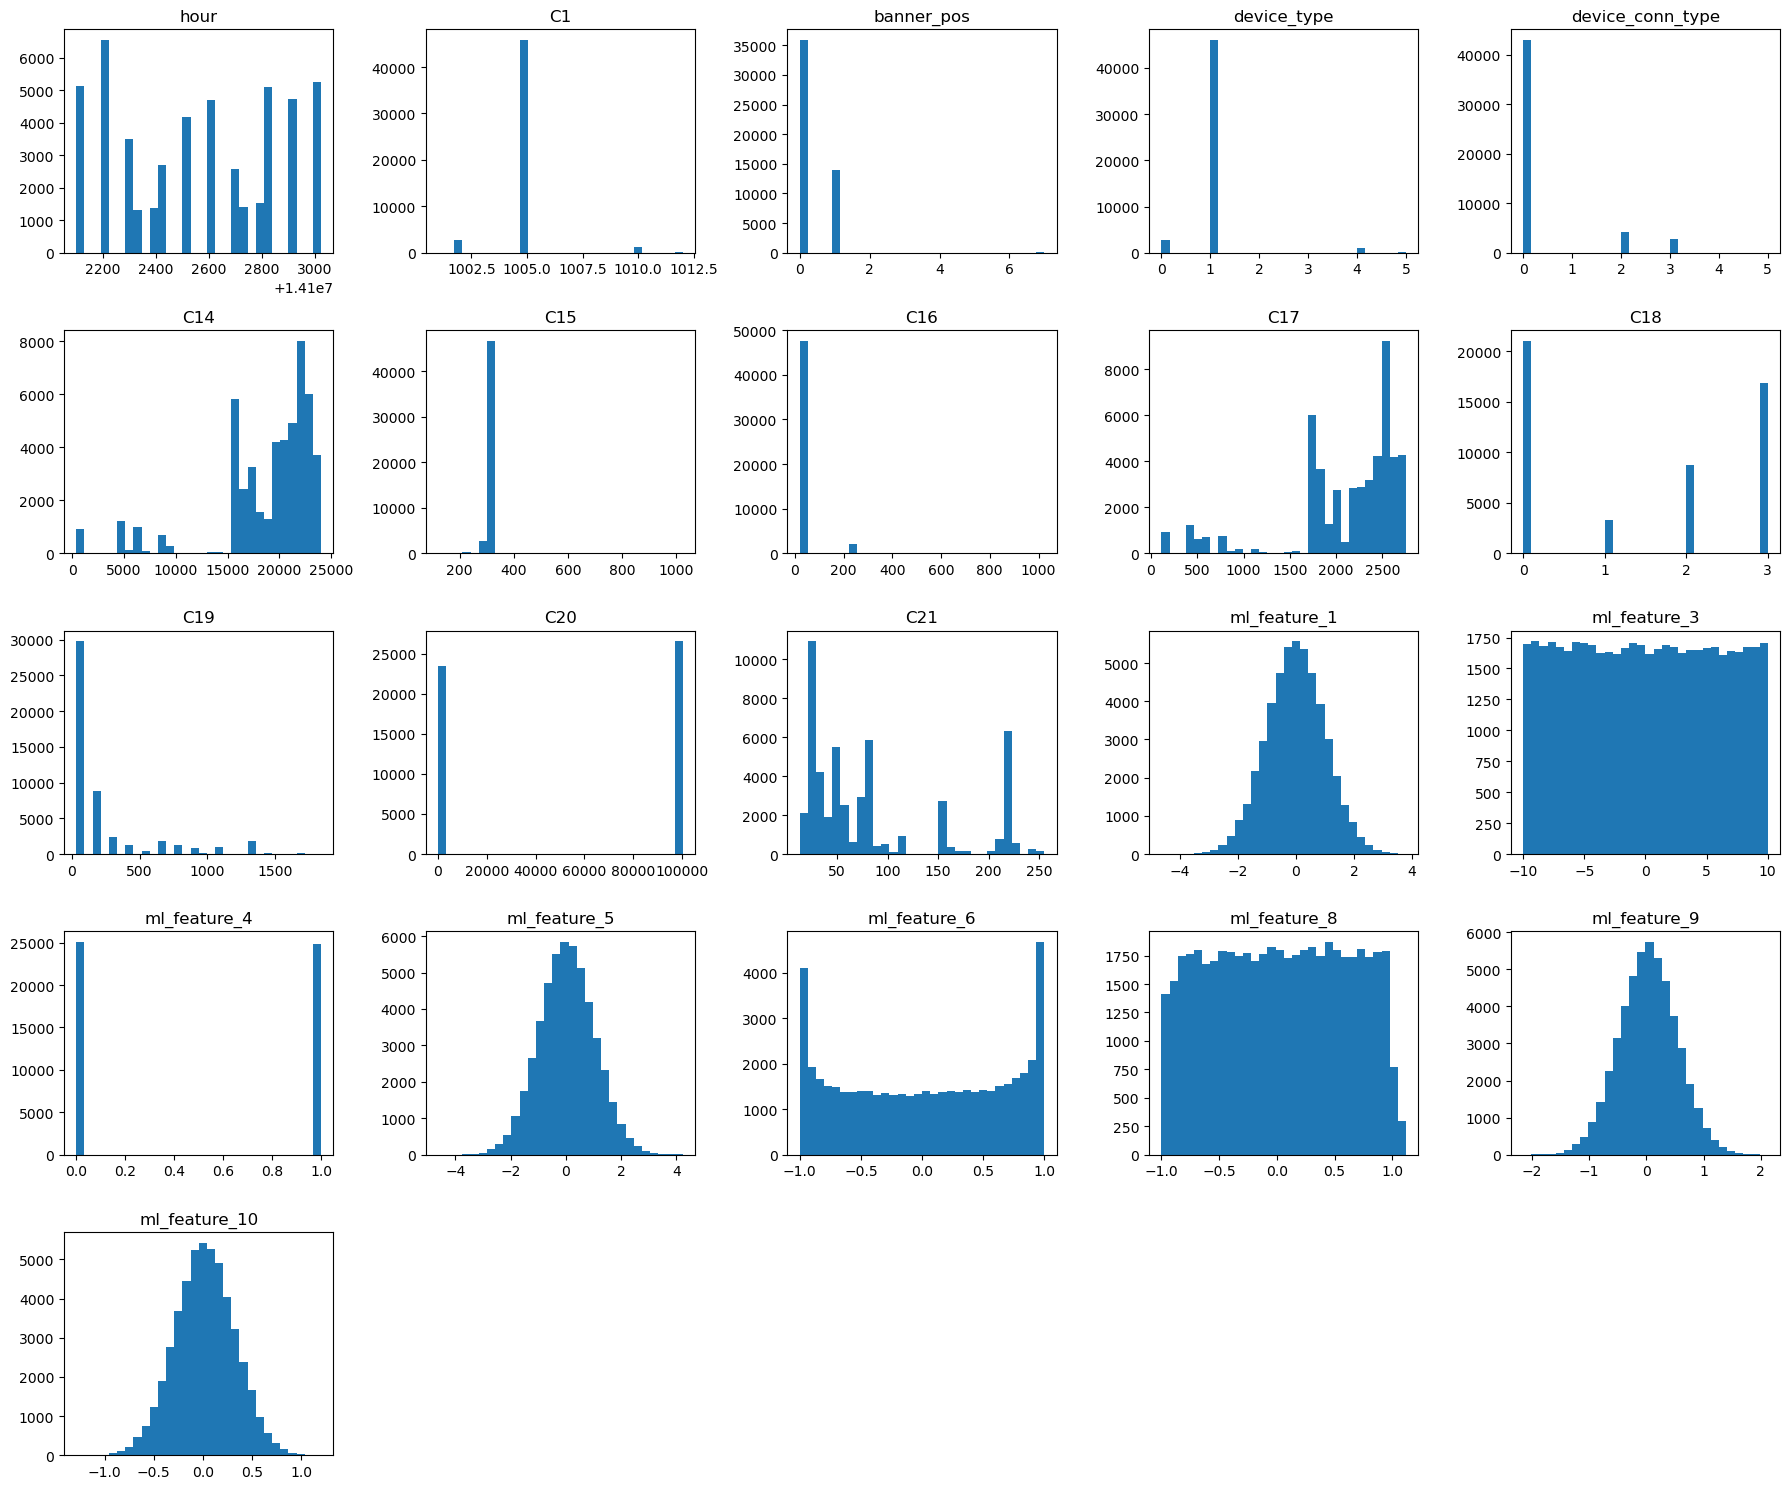

In [26]:
# выведем графики распределений числовых признаков
df[num_cols].hist(
    figsize=(18, 15),
    grid=False,
    bins=30
)
plt.tight_layout()
plt.show()

Проанализируем распределения признаков:
- hour: Отметим цикличность пиков. Характерно для периодического повторения показа баннеров
- группа анонимизированных признаков C1, C15, C16: большинство наблюдений сконцентрировано вокруг одного значения
- device_type: доминирует категория 1, остальные значения практически не встречаются на общем фоне
- banner_pos: дискретное множество представлено в основном значениями 0 и 1; остальные значения - малочисленны
- device_conn_type: ситуация схожа с banner_pos
- C18: Четыре дискретных значения (0, 1, 2, 3). Наибольшая частота у 0

Отдельно выделим признаки с более непрерывным распределением:
- ml_feature 1, 5, 9, 10: имеют классическое нормальное распределение
- ml_feature 3, 6, 8: близки к константным
- ml_feature_4: бинарный флаг
- C14, C17, C21: Распределения имеют сложную форму с локальными максимумами сразу на нескольких значениях. Судя по параметру `skew` признаки C14, C17 имеют заметный хвост слева, C21 - справа
- C19: Распределение, похожее на пуассоновское с сильным правым хвостом
- C20: ярко выраженное бимодальное распределение, но поскольку один из пиков в районе значения 100000, не похоже на бинарный флаг.

---
При асимметричных распределениях с длинными хвостами и нестандартным мульттмодальным характером выбросы скорее являются фичей данных, чем багом.  
Данные имеют разный масштаб и требуют стандартизации.

#### 2.7 Корреляции

Вычисление матрицы phi_k при наличии категориальных признаков высокой кардинальности - трудоемкая задача. Пожертвуем полнотой анализа и определим матрицу корреляций для всех числовых столбцов, включая таргет, а также для категориальных с уровнем кардинальности <= 1500.

In [27]:
interval_cols = [
    'click',
    'hour',
    'C1',
    'banner_pos',
    'device_type',
    'device_conn_type',
    'C14', 'C15', 'C16',
    'C17', 'C18', 'C19',
    'C20', 'C21',
    'ml_feature_1',
    'ml_feature_3',
    'ml_feature_4',
    'ml_feature_5',
    'ml_feature_6',
    'ml_feature_8',
    'ml_feature_9',
    'ml_feature_10'
]

In [28]:
# выборка столбцов для анализа
num_phik_cols = num_cols
cat_phik_cols = [col for col in cat_cols if df[col].nunique() <= 1500]
phik_cols = num_phik_cols + cat_phik_cols + ['click']

In [29]:
# вычисление матрицы phi_k
corr_matrix = df[phik_cols].phik_matrix(
    interval_cols=num_phik_cols+['click']
)

C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_id is large: 1160. Are you sure this is not an interval variable? Analysis for pairs of variables including site_id can be slow.
  warnings.warn(


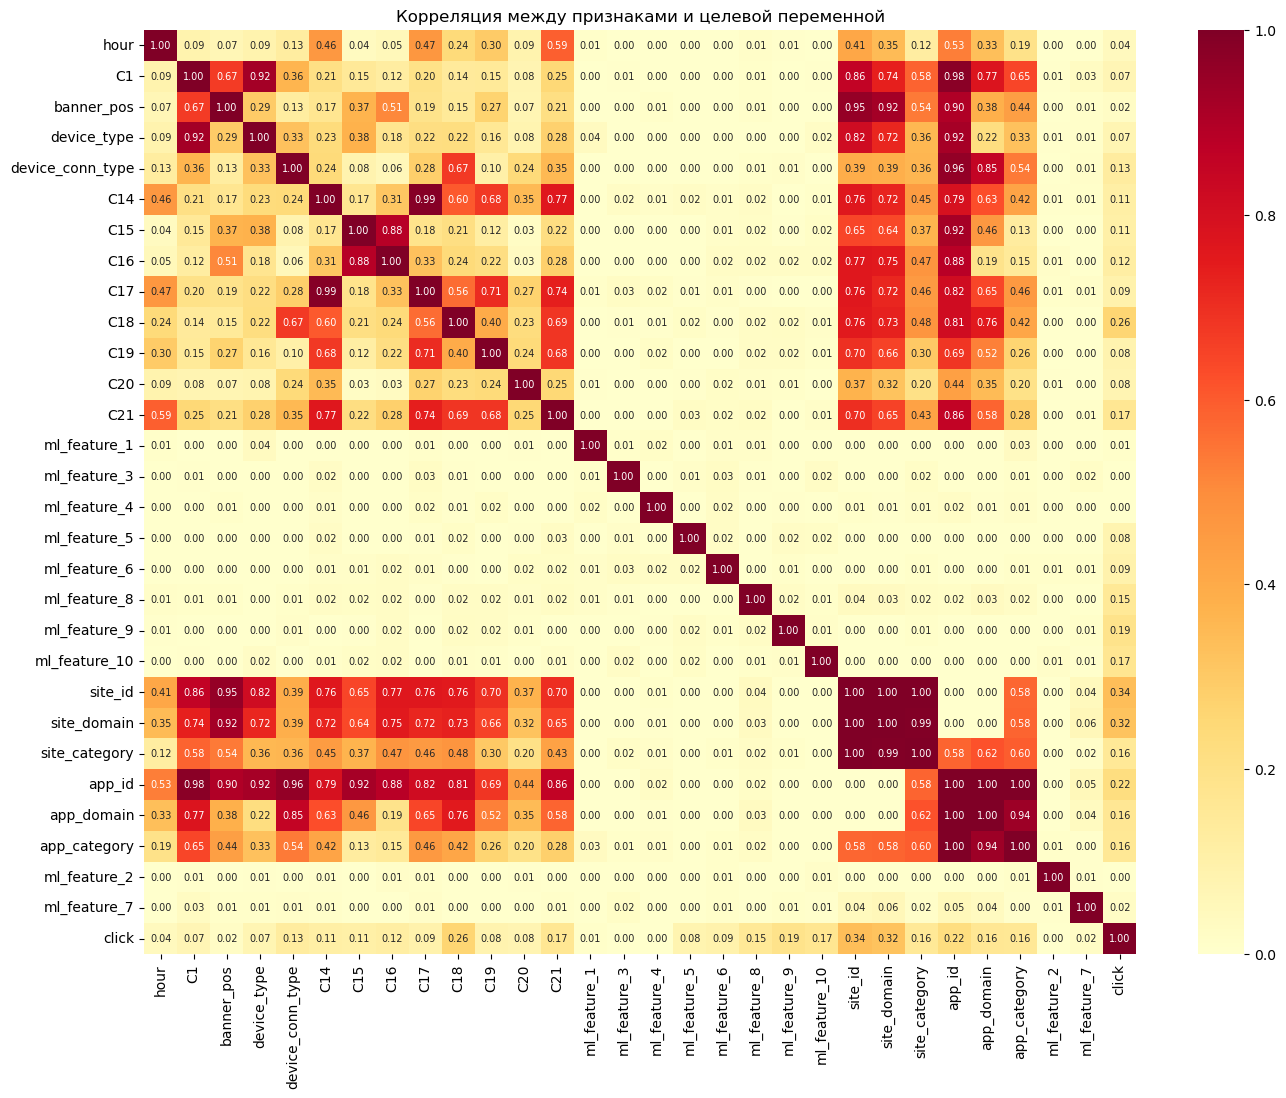

In [30]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, annot_kws={'size': 7}
)
plt.title('Корреляция между признаками и целевой переменной')
plt.show()

In [31]:
print("="*60)
print("Корреляции признаков с целевой переменной")
print("="*60)
round(corr_matrix['click'][corr_matrix.index != 'click'].sort_values(ascending=False), 2)

Корреляции признаков с целевой переменной


site_id             0.34
site_domain         0.32
C18                 0.26
app_id              0.22
ml_feature_9        0.19
ml_feature_10       0.17
C21                 0.17
app_domain          0.16
app_category        0.16
site_category       0.16
ml_feature_8        0.15
device_conn_type    0.13
C16                 0.12
C14                 0.11
C15                 0.11
ml_feature_6        0.09
C17                 0.09
C19                 0.08
ml_feature_5        0.08
C20                 0.08
device_type         0.07
C1                  0.07
hour                0.04
ml_feature_7        0.02
banner_pos          0.02
ml_feature_1        0.01
ml_feature_2        0.00
ml_feature_4        0.00
ml_feature_3        0.00
Name: click, dtype: float64

Определим сильно скоррелированные пары признаков.

In [32]:
corr_threshold = .9
phik_cols = corr_matrix.columns
high_corr_pairs = []

for i in range(len(phik_cols)):
    for j in range(i+1, len(phik_cols)):
        if corr_matrix.loc[phik_cols[i], phik_cols[j]] > corr_threshold:
            high_corr_pairs.append((phik_cols[i], phik_cols[j]))
            
print("="*60)
print(f"Пары сильно скоррелированных признаков, где phi_k > 0.9 ({len(high_corr_pairs)} шт.)")
print("="*60)
high_corr_pairs

Пары сильно скоррелированных признаков, где phi_k > 0.9 (14 шт.)


[('C1', 'device_type'),
 ('C1', 'app_id'),
 ('banner_pos', 'site_id'),
 ('banner_pos', 'site_domain'),
 ('device_type', 'app_id'),
 ('device_conn_type', 'app_id'),
 ('C14', 'C17'),
 ('C15', 'app_id'),
 ('site_id', 'site_domain'),
 ('site_id', 'site_category'),
 ('site_domain', 'site_category'),
 ('app_id', 'app_domain'),
 ('app_id', 'app_category'),
 ('app_domain', 'app_category')]

---
Признаки `ml_feature_` не имеют выраженной связи с остальными и между собой, но для некоторых из них коэффициент `phi_k` ненулевой (в районе 0.1-0.2).  
Признаки `C18`, `C21`, `site_id`, `site_domain`, `app_id` на фоне остальных показывают заметную корреляцию с таргетом (коэффициент от 0.2 до 0.34)  
Выявлено 14 пар сильно скоррелированных признаков, среди которых оставлять в будущем лучше тот, что сильнее скоррелирован с таргетом.

#### 2.8 Выводы по EDA

1. Дисбаланс классов умеренный (4.8:1). PR-AUC - основная метрика.
2. Удален 1 признак без предсказательной способности: уникальный идентификатор `id`.
3. Пропусков нет - предобработка пропусков не требуется.
4. Наиболее информативные признаки по phi_k с `click`: `site_id`, `site_domain`, `C18`, `app_id`, `ml_feature_9`, `ml_feature_10`, `C21`, `app_domain`, `app_category`, `site_category`, `ml_feature_8`, `device_conn_type`, `C16`, `C14`, `C15`.
5. 14 пар сильно скоррелированных признаков - кандидаты на удаление одного из каждой пары.
6. Высококардинальные категориальные признаки `device_id`, `device_model`, `site_id`, `site_domain`, `app_id`, `app_domain`, `app_category`, `site_category` требуют Target Encoding, остальные - OHE.


**Необходимые действия по предобработке**

1. Масштабирование числовых признаков для линейных моделей; выберем стандартизацию.
2. Target Encoding для высококардинальных категориальных признаков.
3. One-Hot Encoding для `ml_feature_2`, `ml_feature_7`.
4. Рассмотреть удаление одного признака из каждой высококоррелированной пары на этапе отбора признаков.

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [33]:
# разделение на признаки и целевую переменную
X = df.drop(columns=['click'])
y = df['click']

In [34]:
# стратифицированное разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

In [35]:
# выведем размеры выборок
print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")

# доля положительного класса
print(f"Процент положительного класса в обучающей выборке: {y_train.mean()*100:.2f}")
print(f"Процент положительного класса в тестовой выборке: {y_test.mean()*100:.2f}")

Размер обучающей выборки: 40000 строк
Размер тестовой выборки: 10000 строк
Процент положительного класса в обучающей выборке: 17.21
Процент положительного класса в тестовой выборке: 17.21


Баланс классов сохранен посредством стратификации.

---

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

#### 4.1 Создайние пайплайна для предобработки данных

In [36]:
# бинарные фичи
binary_features = [
    'ml_feature_4'
]

# численные непрерывные фичи
numeric_features = num_cols
numeric_features.remove('ml_feature_4')

# категориальные фичи для OneHot кодирования
onehot_cat_features = [col for col in cat_cols if df[col].nunique() <= 10]

# категориальные фичи для Target кодирования
target_cat_features = [col for col in cat_cols if col not in onehot_cat_features]

print("="*60)
print(f"Бинарные фичи ({len(binary_features)} шт.):")
print(binary_features)
print("="*60)
print(f"Численные непрерывные фичи ({len(numeric_features)} шт.):")
print(numeric_features)
print("="*60)
print(f"One-hot фичи ({len(onehot_cat_features)} шт.):")
print(onehot_cat_features)
print("="*60)
print(f"Target фичи ({len(target_cat_features)} шт.):")
print(target_cat_features)
print("="*60)

Бинарные фичи (1 шт.):
['ml_feature_4']
Численные непрерывные фичи (20 шт.):
['hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']
One-hot фичи (2 шт.):
['ml_feature_2', 'ml_feature_7']
Target фичи (9 шт.):
['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model']


#### 4.2 Объединение пайплайнов

Поскольку в признаках нет пропусков, заполнение проводить не стоит. Но обученная модель пойдет в продакшн, и по мере ее эксплуатации могут поступить данные с пропусками. Для предупреждения такой ситуации добавим `SimpleImputer` со стратегией заполнения модой для бинарных и категориальных признаков и стратегией заполнения медианой для числовых признаков.

In [37]:
# pipeline бинарных признаков
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# pipeline численных признаков
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# pipeline категориальных признаков
onehot_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# pipeline для категориального признака с большим количеством уник. значений
target_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(
        cv=5,
        smooth=30.0,
        random_state=RANDOM_SEED
    ))
])

In [38]:
# объединение пайплайов
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('bin', binary_pipeline, binary_features),
        ('onehot', onehot_cat_pipeline, onehot_cat_features),
        ('target', target_cat_pipeline, target_cat_features)
    ],
    remainder='drop'
).set_output(transform='pandas')

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

Отбор признаков ведем на основании статистик, вычисленных на **тренировочной выборке**.

#### 5.1 Применение фильтрационных методов

Оценку корреляций с последующими выводами об удалении признака следует проводить только на тренировочной выборке. Одна из стратегий - вычисление phik_matrix на всей "сырой" тренировочной выборке. В случае датасета средних размеров при наличии высококардинальных признаков это слишком трудоемкая задача.  
Перед оценкой корреляций воспользуемся **TargetEncoder с кросс-валидацией** для предотвращения случая, когда таргет-оценка для самой многочисленной категории просто практически повторит ее глобальное среднее и коэффициент phik, ровно как и MI, улетят "в космос".  
При этом остальные признаки оставим без изменений.

**Target encoding с кросс-валидацией**

Повторно выведем высококардинальные признаки:

In [39]:
cardinal

device_ip        41455
device_id         8580
device_model      2521
site_id           1160
site_domain       1013
app_id             976
app_domain          67
app_category        22
site_category       18
ml_feature_2         5
ml_feature_7         3
dtype: int64

In [40]:
high_cardinality_features = cardinal[cardinal>10].index.to_list()
high_cardinality_features

['device_ip',
 'device_id',
 'device_model',
 'site_id',
 'site_domain',
 'app_id',
 'app_domain',
 'app_category',
 'site_category']

In [41]:
# энкодер с заполнением пропусков
target_cv_encoder = ColumnTransformer(
    transformers=[
        ('target_cv', target_cat_pipeline, high_cardinality_features)
    ],
    remainder='passthrough'
).set_output(transform='pandas')

In [42]:
X_train_encoded = target_cv_encoder.fit_transform(X_train, y_train)

**Корреляции**

Определим коэффициенты корреляции признаков обработанной тренировочной выборки с таргетом

In [43]:
# объединяем признаки и таргет
df_phik = X_train_encoded.copy()
df_phik["click"] = y_train

In [44]:
corr_matrix_processed = df_phik.phik_matrix()

interval columns not set, guessing: ['target_cv__device_ip', 'target_cv__device_id', 'target_cv__device_model', 'target_cv__site_id', 'target_cv__site_domain', 'target_cv__app_id', 'target_cv__app_domain', 'target_cv__app_category', 'target_cv__site_category', 'remainder__hour', 'remainder__C1', 'remainder__banner_pos', 'remainder__device_type', 'remainder__device_conn_type', 'remainder__C14', 'remainder__C15', 'remainder__C16', 'remainder__C17', 'remainder__C18', 'remainder__C19', 'remainder__C20', 'remainder__C21', 'remainder__ml_feature_1', 'remainder__ml_feature_3', 'remainder__ml_feature_4', 'remainder__ml_feature_5', 'remainder__ml_feature_6', 'remainder__ml_feature_8', 'remainder__ml_feature_9', 'remainder__ml_feature_10', 'click']


In [45]:
# выводим корреляции с таргетом
corr_click = corr_matrix_processed['click'][corr_matrix_processed['click'].index != 'click'].sort_values(ascending=False)

# коэффициенты phi_k
corr_click

target_cv__site_id             0.337619
target_cv__site_domain         0.313830
remainder__C18                 0.256649
target_cv__app_id              0.218441
remainder__ml_feature_9        0.196155
target_cv__device_model        0.180617
target_cv__app_domain          0.172851
remainder__ml_feature_10       0.170019
remainder__C21                 0.168478
remainder__ml_feature_8        0.146308
remainder__device_conn_type    0.131398
target_cv__app_category        0.124992
target_cv__site_category       0.123301
remainder__C16                 0.118537
remainder__C14                 0.117620
remainder__C15                 0.106465
remainder__C17                 0.092451
remainder__C19                 0.087717
remainder__ml_feature_6        0.086385
remainder__ml_feature_5        0.083569
target_cv__device_id           0.082141
remainder__C20                 0.075567
remainder__device_type         0.073552
remainder__C1                  0.068843
target_cv__device_ip           0.063266


In [46]:
phik_to_drop = corr_click[corr_click == 0.0].index.to_list()
print("="*60)
print(f"Признаки с нулевым коэффициентом phi_k ({len(phik_to_drop)} шт.)")
phik_to_drop

Признаки с нулевым коэффициентом phi_k (3 шт.)


['remainder__ml_feature_4',
 'remainder__ml_feature_3',
 'remainder__ml_feature_1']

**Константные признаки**

Применение класса VarianceThreshold лишено смысла, если признаки масштабированы (особенно, если их стандартизировали и привели к единичной дисперсии). Применяем VarianceThreshold к немасштабированной закодированной тренировочной выборке.

Определим, какие столбцы в закодированной выборке являются числовыми, какие - категориальными.

In [47]:
num_encoded_cols = X_train_encoded.select_dtypes(include=[np.number]).columns.tolist()
cat_encoded_cols = X_train_encoded.select_dtypes(include='object').columns.tolist()

In [48]:
# выявление константных числовых признаков
vt = VarianceThreshold(threshold=.0)
vt.fit(X_train_encoded[num_encoded_cols])
num_const_to_drop = [col for col, keep in zip(X_train_encoded[num_encoded_cols].columns, vt.get_support()) if not keep]

print("="*60)
print(f"Константные числовые признаки ({len(num_const_to_drop)} шт.)")
num_const_to_drop

Константные числовые признаки (0 шт.)


[]

In [49]:
# выявление константных категориальных признаков
cat_const_to_drop = [col for col in X_train_encoded.select_dtypes(include='object').columns if X_train_encoded[col].nunique() == 1]

print("="*60)
print(f"Константные категориальные признаки ({len(cat_const_to_drop)} шт.)")
cat_const_to_drop

Константные категориальные признаки (0 шт.)


[]

**Квазиконстантные признаки**

In [50]:
# выявление квазиконстантных числовых признаков
vt_quasi = VarianceThreshold(threshold=.001)
vt_quasi.fit(X_train_encoded[num_encoded_cols])
num_quasiconst_to_drop = [col for col, keep in zip(X_train_encoded[num_encoded_cols].columns, vt_quasi.get_support()) if not keep]

print("="*60)
print(f"Квазиконстантные числовые признаки ({len(num_quasiconst_to_drop)} шт.)")
num_quasiconst_to_drop

Квазиконстантные числовые признаки (2 шт.)


['target_cv__device_ip', 'target_cv__device_id']

In [51]:
# выявление константных категориальных признаков
cat_quasiconst_to_drop = [col for col in X_train_encoded.select_dtypes(include='object').columns if (X_train_encoded[col].nunique() / len(X_train_encoded[col])) > .9]

print("="*60)
print(f"Квазиконстантные категориальные признаки ({len(cat_quasiconst_to_drop)} шт.)")
cat_quasiconst_to_drop

Квазиконстантные категориальные признаки (0 шт.)


[]

In [52]:
X_train['device_id'].value_counts()

device_id
a99f214a    32947
c357dbff       23
0f7c61dc       21
936e92fb       10
afeffc18        9
            ...  
c6392948        1
85466776        1
64b13923        1
0b18dcb2        1
d622bb10        1
Name: count, Length: 6911, dtype: int64

---
Отметим **особенность** работы TargetEncoder с кросс-валидацией.
- при кодировании высококардинального `device_ip` с кросс валидацией значение таргета для текущей (и почти всегда уникальной в случае `device_ip`) категории рассчитывалась по остальным фолдам, т.е. по фолдам, где нет текущей категории. Из-за этого почти для всех значений (а они почти все уникальны) было подставлено глобальное среднее таргета, которое практически повторяет долю положительного класса. Получили квази-константу. Для малой доли неуникальных значений, встречающихся в `device_ip`, кодирование могло дать что угодно, в зависимости от того, какой таргет был в рамках этой категории. Получили в итоге ситуацию где для всех уникальных категорий энкодер дал среднее таргета, а для остальных категорий - кучу выбросов. Под эти выбросы будет подстраиваться любая линейная модель и переучиваться (в том числе в грядущем RFE, где этот признак получит скорее всего хороший ранг и останется после отбора). 
- при кодировании `device_ip` мы получили по сути ту же картину, но по диаметрально противоположной причине: подавляющее большинство значений были уже одинаковы в сырых данных. При их кодировании волей-неволей получится практически глобальное среднее таргета, а для остальных значений - что угодно.

Эти признаки надо удалить из данных уже сейчас, потому что на этапе RFE мы уже получим переобучение и аномально низкий ranking для `device_ip` и `device_ip` (т.е. метод точно отберет эти признаки по важности).

In [53]:
target_cat_features.remove('device_id')
target_cat_features.remove('device_ip')

#### 5.2 Применение методов-обёрток

Поскольку estimator'ом в методе-обертке будет выбрана линейная модель, необходимо передать ему числовые масштабированные признаки. Применим к тренировочной выборке препроцессор, написанный в пункте 4.

In [54]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)

В качестве метода-обертки выберем RFE, поскольку он является балансом между прямым и обратным методами.

In [55]:
num_features_to_select = 20

model = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=RANDOM_SEED)

rfe_selector = RFE(estimator=model,
                   n_features_to_select=num_features_to_select,
                   step=1,
                   verbose=0)

# обучаем RFE на обучающих данных
rfe_selector.fit(X_train_processed, y_train)


RFE(estimator=LogisticRegression(class_weight='balanced', max_iter=1000,
                                 random_state=42, solver='liblinear'),
    n_features_to_select=20)

In [56]:
# Получаем информацию о выбранных признаках
selected_rfe_features = X_train_processed.columns[rfe_selector.support_].tolist()
print(f'\nВыбранные признаки RFE ({num_features_to_select}): {selected_rfe_features}')
print("="*60)
print()
for feature, rank in zip(X_train_processed.columns, rfe_selector.ranking_):
    print(f'Признак: {feature}, Ранг: {rank}')


Выбранные признаки RFE (20): ['num__ml_feature_5', 'num__ml_feature_6', 'num__ml_feature_8', 'num__ml_feature_9', 'num__ml_feature_10', 'onehot__ml_feature_2_A', 'onehot__ml_feature_2_B', 'onehot__ml_feature_2_C', 'onehot__ml_feature_2_D', 'onehot__ml_feature_2_E', 'onehot__ml_feature_7_X', 'onehot__ml_feature_7_Y', 'onehot__ml_feature_7_Z', 'target__site_id', 'target__site_domain', 'target__site_category', 'target__app_id', 'target__app_domain', 'target__app_category', 'target__device_model']

Признак: num__hour, Ранг: 10
Признак: num__C1, Ранг: 6
Признак: num__banner_pos, Ранг: 14
Признак: num__device_type, Ранг: 7
Признак: num__device_conn_type, Ранг: 12
Признак: num__C14, Ранг: 2
Признак: num__C15, Ранг: 9
Признак: num__C16, Ранг: 15
Признак: num__C17, Ранг: 3
Признак: num__C18, Ранг: 5
Признак: num__C19, Ранг: 8
Признак: num__C20, Ранг: 11
Признак: num__C21, Ранг: 4
Признак: num__ml_feature_1, Ранг: 13
Признак: num__ml_feature_3, Ранг: 16
Признак: num__ml_feature_5, Ранг: 1
Призн

#### 5.3 Выбор финального набора признаков

Результат анализа корреляций:

In [57]:
phik_to_drop = corr_click[corr_click == 0.0].index.to_list()
print("="*60)
print(f"Признаки с нулевым коэффициентом phi_k ({len(phik_to_drop)} шт.)")
phik_to_drop

Признаки с нулевым коэффициентом phi_k (3 шт.)


['remainder__ml_feature_4',
 'remainder__ml_feature_3',
 'remainder__ml_feature_1']

Константных признаков нет. Квазиконстантные признаки:

In [58]:
print("="*60)
print(f"Квазиконстантные числовые признаки ({len(num_quasiconst_to_drop)} шт.)")
num_quasiconst_to_drop

Квазиконстантные числовые признаки (2 шт.)


['target_cv__device_ip', 'target_cv__device_id']

Результат RFE трактовать затруднительно. Отобранные признаки - лишь результат обучения конкретной модели с конкретными параметрами и при конкретных настройках оберточного метода. Можем лишь удостовериться в том, что признаки с нулевой корреляцией phi_k (`ml_feature_4`, `ml_feature_3`, `ml_feature_1`) в совокупности и с другими признаками (то есть внутри конкретной ML-модели) получили небольшую значимости (ranking RFE равны 17, 16 и 13 соответственно)

---

Также для упрощения модели и борьбы с мультиколлинеарностью принято решение помимо признаков с нулевой корреляцией (`ml_feature_4`, `ml_feature_3`, `ml_feature_1`) и квазиконтсантных после кодирования (`device_ip`, `device_id`) удалить пары сильно скоррелированных признаков.  
Логика удаления была следующей: определялись группы признаков, связанных сильной корреляцией phi_k между собой. Среди них оставляем те, что сильнее других в своей группе связаны с таргетом.  
Таким образом было дополнительно удалено: `banner_pos`, `C1`, `device_type`, `C17`, `site_domain`, `site_category`, `app_domain`, `app_category`. 

In [59]:
# для удаления достаточно не включать признаки в вывод препроцессора
numeric_features = [col for col in numeric_features if col not in ['ml_feature_3', 'ml_feature_1', 'banner_pos', 'C1', 'device_type', 'C17']]
binary_features = [col for col in binary_features if col not in ['ml_feature_4']]
target_cat_features = [col for col in target_cat_features if col not in ['site_domain', 'site_category', 'app_domain', 'app_category']]
print(numeric_features)
print(binary_features)
print(onehot_cat_features)
print(target_cat_features)

['hour', 'device_conn_type', 'C14', 'C15', 'C16', 'C18', 'C19', 'C20', 'C21', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']
[]
['ml_feature_2', 'ml_feature_7']
['site_id', 'app_id', 'device_model']


In [60]:
# переобозначаем препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('bin', binary_pipeline, binary_features),
        ('onehot', onehot_cat_pipeline, onehot_cat_features),
        ('target', target_cat_pipeline, target_cat_features)
    ],
    remainder='drop'
).set_output(transform='pandas')

In [61]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['hour', 'device_conn_type', 'C14', 'C15',
                                  'C16', 'C18', 'C19', 'C20', 'C21',
                                  'ml_feature_5', 'ml_feature_6',
                                  'ml_feature_8', 'ml_feature_9',
                                  'ml_feature_10']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')...
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['ml_feature_2', 'ml_feature_7']),
                                ('target',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('target_encoder',
                                                  TargetEncoder(random_state=42,
                                                                smooth=30.0))]),
                                 ['site_id', 'app_id', 'device_model'])])

---
На этапе отбора признаков удалены:
- числовые `ml_feature_4`, `ml_feature_3`, `ml_feature_1` (нулевая линейная связь с таргетом и малый вес по выводам модели-обертки
- категориальные `device_ip`, `device_id` (высокая кардинальность и переобучение после TargetEncoder)
- сильно скоррелированные `banner_pos`, `C1`, `device_type`, `C17`, `site_domain`, `site_category`, `app_domain`, `app_category`

In [62]:
print("="*60)
print(f"Дальнейшее обучение модели происходит на {len(numeric_features) + len(binary_features) + len(onehot_cat_features) + len(target_cat_features)} признаках")
print("="*60)

Дальнейшее обучение модели происходит на 19 признаках


## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

In [63]:
# стратегия разбиения на фолды со стратификацией 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# метрики, замеряемые на тестовых фолдах
scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'pr_auc': 'average_precision'
}

#### 6.1 Обучение `DummyClassifier`

In [64]:
# pipeline препроцессор + модель
dummy_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='stratified', random_state=RANDOM_SEED))
])

# кросс-валидация
dummy_res = cross_validate(
    estimator=dummy_pipeline,
    X=X_train, y=y_train,
    cv=cv,
    n_jobs=-1,
    scoring=scoring
)

print("="*60)
print(f"PR-AUC по фолдам: {dummy_res['test_pr_auc'].round(3)}")

print("="*60)
print(f"PR-AUC mean +- std: {dummy_res['test_pr_auc'].mean():.4f} +- {dummy_res['test_pr_auc'].std():.4f}")

PR-AUC по фолдам: [0.172 0.171 0.17  0.171 0.171]
PR-AUC mean +- std: 0.1710 +- 0.0007


#### 6.2 Обучение `LogisticRegression`

In [65]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_SEED
    ))
])

# кросс-валидация
lr_res = cross_validate(
    estimator=lr_pipeline,
    X=X_train, y=y_train,
    cv=cv,
    n_jobs=-1,
    scoring=scoring
)

print("="*60)
print(f"PR-AUC по фолдам: {lr_res['test_pr_auc'].round(3)}")

print("="*60)
print(f"PR-AUC mean +- std: {lr_res['test_pr_auc'].mean():.3f} +- {lr_res['test_pr_auc'].std():.3f}")
print(f"Precision: {lr_res['test_precision'].mean():.3f}")
print(f"Recall: {lr_res['test_recall'].mean():.3f}")
print(f"F1: {lr_res['test_f1'].mean():.3f}")

PR-AUC по фолдам: [0.4   0.409 0.423 0.427 0.41 ]
PR-AUC mean +- std: 0.414 +- 0.010
Precision: 0.312
Recall: 0.692
F1: 0.430


#### 6.3 Обучение `SVC`

In [66]:
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(
        max_iter=5000,
        tol=1e-3,
        dual=False,
        class_weight='balanced',
        random_state=RANDOM_SEED
    ))
])

# кросс-валидация
svc_res = cross_validate(
    estimator=svc_pipeline,
    X=X_train, y=y_train,
    cv=cv,
    n_jobs=-1,
    scoring=scoring
)

print("="*60)
print(f"PR-AUC по фолдам: {svc_res['test_pr_auc'].round(3)}")

print("="*60)
print(f"PR-AUC mean +- std: {svc_res['test_pr_auc'].mean():.3f} +- {svc_res['test_pr_auc'].std():.3f}")
print(f"Precision: {svc_res['test_precision'].mean():.3f}")
print(f"Recall: {svc_res['test_recall'].mean():.3f}")
print(f"F1: {svc_res['test_f1'].mean():.3f}")

PR-AUC по фолдам: [0.4   0.41  0.423 0.427 0.411]
PR-AUC mean +- std: 0.414 +- 0.010
Precision: 0.311
Recall: 0.693
F1: 0.429


#### 6.4 Сравнение моделей

In [67]:
compare_models = pd.DataFrame({
    'Модель': ['DummyClassifier', 'LogisticRegression', 'LinearSVC'],
    'PR-AUC': [round(dummy_res['test_pr_auc'].mean(), 4), round(lr_res['test_pr_auc'].mean(), 4), round(svc_res['test_pr_auc'].mean(), 4)]
})

print("="*60)
print("Сравнение моделей по PR-AUC")
compare_models

Сравнение моделей по PR-AUC


,Модель,PR-AUC
0,DummyClassifier,0.1710
1,LogisticRegression,0.4138
2,LinearSVC,0.4142


---
- LogisticRegression лучше DummyClassifier: PR-AUC вырос с 0.171 до 0.414, то есть в 2.42 раза. Модель логрега улучшила способность предсказывать клики относительно случайного угадывания.
- LinearSVC практически неотличим от LogisticRegression: разница в PR-AUC порядка 0.0004. Обе модели линейные и работают с одинаковым набором признаков, поэтому такой результат ожидаем.

- Значение PR-AUC 0.41 - умеренный результат для задачи предсказания кликов с таким набором признаков. Линейные модели в 2.4 раза лучше baseline и очевидно уловили закономерности.

- Поскольку признаки анонимизированы, задачу feature_engineering не реализовать. Одним из способов увеличения качества модели может стать удаление сильно скоррелированных признаков и применение нелинейных ядер в SVM.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

Поскольку SVC с нелинейными ядрами работает кратно дольше и имеет намного большую алгоритмическую сложность в сравнении с LinearSVC, было принято решение в рамках проекта GridSearch проводить для LinearSVC.  
Помимо этого тестовый прогон GridSearch с SVC с нелинейными ядрами длился несколько часов и давал метрики хуже, чем LinearSVC.

#### 7.1 Определение сетки гиперпараметров

In [68]:
# сетка для LogReg
lr_param_grid = {
    'lr__C': [0.1, 1.0],
    'lr__penalty': ['l1', 'l2'],
    'lr__class_weight': ['balanced', None],
    'lr__solver': ['liblinear'],
    'lr__max_iter': [100, 1000]
}

In [69]:
# сетка для LinearSVC
svc_param_grid = {
    'svc__C': [0.001, 0.01, 0.1, 1],
    'svc__class_weight': [None, 'balanced'],
    'svc__dual': ['auto', False],
    'svc__max_iter': [1000, 5000]
}

In [70]:
# сетка для SVC
svc_hard_param_grid = {
    'svc_hard__C': [0.1, 1, 10],
    'svc_hard__kernel': ['rbf', 'poly'],
    'svc_hard__gamma': ['scale', 'auto']
}

In [71]:
lr_comb = 5 * 2 * 2 * 2
svc_comb = 3 * 5 * 2
print(f"LogisticRegression: {lr_comb} комбинаций")
print(f"SVC: {svc_comb} комбинаций")

LogisticRegression: 40 комбинаций
SVC: 30 комбинаций


#### 7.2 Применение Grid Search

**Варьирование параметров LogisticRegression**

In [72]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(random_state=RANDOM_SEED))
])

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1
)

In [73]:
t1 = time()
lr_grid_search.fit(X_train, y_train)
t2 = time()
print(f"Лучшие параметры LR:")
for param, value in lr_grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"Лучший PR-AUC: {lr_grid_search.best_score_:.4f}")
print(f"Готово за {round((t2 - t1) // 60)} минут {round((t2 - t1) % 60)} секунд")

Лучшие параметры LR:
lr__C: 1.0
lr__class_weight: None
lr__max_iter: 100
lr__penalty: l1
lr__solver: liblinear
Лучший PR-AUC: 0.4148
Готово за 10 минут 33 секунд


**Варьирование параметров LinearSVC**

In [74]:
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svc', LinearSVC(random_state=RANDOM_SEED))
])

svc_grid_search = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=svc_param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1
)

In [75]:
t1 = time()
svc_grid_search.fit(X_train, y_train)
t2 = time()

print(f"Лучшие параметры SVC:")
for param, value in svc_grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"Лучший PR-AUC: {svc_grid_search.best_score_:.4f}")
print(f"Готово за {round((t2 - t1) // 60)} минут {round((t2 - t1) % 60)} секунд")

Лучшие параметры SVC:
svc__C: 1
svc__class_weight: balanced
svc__dual: auto
svc__max_iter: 1000
Лучший PR-AUC: 0.4143
Готово за 1 минут 13 секунд


**Варьирование параметров SVC с нелинейными ядрами**

In [76]:
svc_hard_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svc_hard', SVC(random_state=RANDOM_SEED))
])

svc_hard_grid_search = GridSearchCV(
    estimator=svc_hard_pipeline,
    param_grid=svc_hard_param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1
)

Для экономии ресурса вычленим малую выборку из тренировочной:

In [77]:
# стратифицированное разделение
X_train_svc, X_temp, y_train_svc, y_temp = train_test_split(
    X_train, y_train,
    test_size=0.75,
    random_state=RANDOM_SEED,
    stratify=y_train
)

In [78]:
t1 = time()
svc_hard_grid_search.fit(X_train_svc, y_train_svc)
t2 = time()

print(f"Лучшие параметры SVC:")
for param, value in svc_hard_grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"Лучший PR-AUC: {svc_hard_grid_search.best_score_:.4f}")
print(f"Готово за {round((t2 - t1) // 60)} минут {round((t2 - t1) % 60)} секунд")

Лучшие параметры SVC:
svc_hard__C: 0.1
svc_hard__gamma: auto
svc_hard__kernel: rbf
Лучший PR-AUC: 0.3225
Готово за 2 минут 28 секунд


---
Метрики тяжелой модели SVC с нелинейным ядром критически хуже метрик линейных моделей. Далее SVC с rbf не разбираем.

#### 7.3 Составление таблицы результатов

Лучшие результаты LogReg

In [79]:
# DataFrame для удобства обработки
lr_df = pd.DataFrame(lr_grid_search.cv_results_)

In [80]:
top_10_lr = lr_df[[
    'params', 
    'mean_test_score', 
    'std_test_score', 
    'rank_test_score'
]].sort_values(by='rank_test_score').head(10).reset_index(drop=True)
print("="*60)
print("Топ-10 наборов параметров для LogisticRegression:")
display(top_10_lr)

Топ-10 наборов параметров для LogisticRegression:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'lr__C': 1.0, 'lr__class_weight': None, 'lr__max_iter': 100, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}",0.414806,0.009847,1
1,"{'lr__C': 1.0, 'lr__class_weight': None, 'lr__max_iter': 1000, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}",0.414806,0.009847,1
2,"{'lr__C': 1.0, 'lr__class_weight': 'balanced', 'lr__max_iter': 100, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}",0.414216,0.009799,3
3,"{'lr__C': 1.0, 'lr__class_weight': 'balanced', 'lr__max_iter': 1000, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}",0.414216,0.009799,3
4,"{'lr__C': 1.0, 'lr__class_weight': None, 'lr__max_iter': 100, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}",0.414151,0.010086,5
5,"{'lr__C': 1.0, 'lr__class_weight': None, 'lr__max_iter': 1000, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}",0.414151,0.010086,5
6,"{'lr__C': 1.0, 'lr__class_weight': 'balanced', 'lr__max_iter': 100, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}",0.413837,0.009917,7
7,"{'lr__C': 1.0, 'lr__class_weight': 'balanced', 'lr__max_iter': 1000, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}",0.413837,0.009917,7
8,"{'lr__C': 0.1, 'lr__class_weight': 'balanced', 'lr__max_iter': 100, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}",0.413679,0.010033,9
9,"{'lr__C': 0.1, 'lr__class_weight': 'balanced', 'lr__max_iter': 1000, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}",0.413679,0.010033,9


Лучшие результаты LinearSVC

In [81]:
# DataFrame для удобства обработки
svc_df = pd.DataFrame(svc_grid_search.cv_results_)

In [82]:
top_10_svc = svc_df[[
    'params', 
    'mean_test_score', 
    'std_test_score', 
    'rank_test_score'
]].sort_values(by='rank_test_score').head(10).reset_index(drop=True)
print("="*60)
print("Топ-10 наборов параметров для LinearSVC:")
display(top_10_svc)

Топ-10 наборов параметров для LinearSVC:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__dual': False, 'svc__max_iter': 5000}",0.414257,0.009679,1
1,"{'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__dual': 'auto', 'svc__max_iter': 5000}",0.414257,0.009679,1
2,"{'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__dual': 'auto', 'svc__max_iter': 1000}",0.414257,0.009679,1
3,"{'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__dual': False, 'svc__max_iter': 1000}",0.414257,0.009679,1
4,"{'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__dual': False, 'svc__max_iter': 5000}",0.413995,0.009862,5
5,"{'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__dual': False, 'svc__max_iter': 1000}",0.413995,0.009862,5
6,"{'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__dual': 'auto', 'svc__max_iter': 5000}",0.413995,0.009862,5
7,"{'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__dual': 'auto', 'svc__max_iter': 1000}",0.413995,0.009862,5
8,"{'svc__C': 0.01, 'svc__class_weight': 'balanced', 'svc__dual': False, 'svc__max_iter': 1000}",0.410756,0.010265,9
9,"{'svc__C': 0.01, 'svc__class_weight': 'balanced', 'svc__dual': 'auto', 'svc__max_iter': 5000}",0.410756,0.010265,9


## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

#### 8.1 Обучение финальной модели

К лучшей модели+препроцессору обратимся через атрибут best_estimator_ класса GridSearch:

**LogisticRegression**

In [83]:
# лучшая модель с препроцессором
lr_best = lr_grid_search.best_estimator_

lr_best.fit(X_train, y_train)
y_lr_score = lr_best.predict_proba(X_test)[:, 1]

**LinearSVC**

Поскольку в рамках структуры проекта изначально не требовалось возвращать скоры, воспользуемся decision_function. Она подойдет для расчета PR-AUC, так как сохраняет ранжирование, хоть и возвращает расстояния.

In [84]:
# лучшая модель с препроцессором
svc_best = svc_grid_search.best_estimator_

svc_best.fit(X_train, y_train)
y_svc_score = svc_best.decision_function(X_test)

#### 8.2 Расчет метрик на тестовой выборке

**LogisticRegression**

In [85]:
PR_AUC_lr = average_precision_score(y_test, y_lr_score)
brier_score_lr = brier_score_loss(y_test, y_lr_score)

**LinearSVC**

Дя расчета оценки Бриера требуются вероятности. Применим сигмоидальное преобразование для заключения результатов decision_function в интервал (0; 1).

In [86]:
# расчет сырых вероятностей через сигмоиду
y_svc_score_sigm = 1 / (1 + np.e**(-y_svc_score))

In [87]:
PR_AUC_svc = average_precision_score(y_test, y_svc_score)
brier_score_svc = brier_score_loss(y_test, y_svc_score_sigm)

Сравнение

In [88]:
print("="*60)
print(f"PR-AUC логистической регрессии: {round(PR_AUC_lr, 4)}")
print(f"Оценка Бриера логистической регрессии: {round(brier_score_lr, 4)}")
print("="*60)
print(f"PR-AUC LinearSVC: {round(PR_AUC_svc, 4)}")
print(f"Оценка Бриера LinearSVC: {round(brier_score_svc, 4)}")
print("="*60)

PR-AUC логистической регрессии: 0.3994
Оценка Бриера логистической регрессии: 0.1246
PR-AUC LinearSVC: 0.3985
Оценка Бриера LinearSVC: 0.2146


---
Основная метрика PR-AUC, учитывающая дисбаланс классов, для обеих моделей на тестовой выборке снизилась, но незначительно. Переобучения нет и модели ведут себя стабильно.  
Оценка Бриера для логистической регрессии ниже, что говорит о более хорошей откалиброванности модели. Предсказанные ею вероятности лучше совпадают с реальной частотой кликов, чем в случае LinearSVC.

#### 8.3 Анализ весов модели

In [89]:
# df весов логрега
lr_coef = pd.DataFrame({
    'feature': lr_best['lr'].feature_names_in_,
    'coefficient_lr': lr_best['lr'].coef_[0]
})

In [90]:
# df весов LinearSVC
svc_coef = pd.DataFrame({
    'feature': svc_best['svc'].feature_names_in_,
    'coefficient_svc': svc_best['svc'].coef_[0]
})

Сравним коэффициенты, вычисленные для каждого из признаков разными моделями классификации:

In [91]:
coef_comparison = pd.merge(lr_coef, svc_coef, on='feature', how = 'inner').sort_values(by='coefficient_lr', ascending=False)
print("="*60)
print("Сравнение коэффициентов")
print("="*60)
coef_comparison 

Сравнение коэффициентов


,feature,coefficient_lr,coefficient_svc
23,target__app_id,7.979274,3.026770
22,target__site_id,5.351380,2.299481
24,target__device_model,2.804044,1.131314
12,num__ml_feature_9,0.415318,0.169339
13,num__ml_feature_10,0.352919,0.144278
11,num__ml_feature_8,0.206511,0.083802
10,num__ml_feature_6,0.170452,0.069371
9,num__ml_feature_5,0.168364,0.068822
6,num__C19,0.052765,0.019281
15,onehot__ml_feature_2_B,0.045313,-0.135458


---
Заметим, что самые важные признаки для моделей одинаковы что в случае LogisticRegression, что в случае LinearSVC. Топ 5 признаков по важности для обеих моделей:
- `app_id`, `site_id`, `device_model`, `ml_feature_9`, `ml_feature_10`  

Поскольку три из топ-5 признаков получены кодированием через таргет, а два машинно сгенерированы, интерпретировать связь признака и таргета через веса проблематично. 

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

#### 9.1 Проверка текущей калибровки

**Проверка калибровки LogisticRegression**

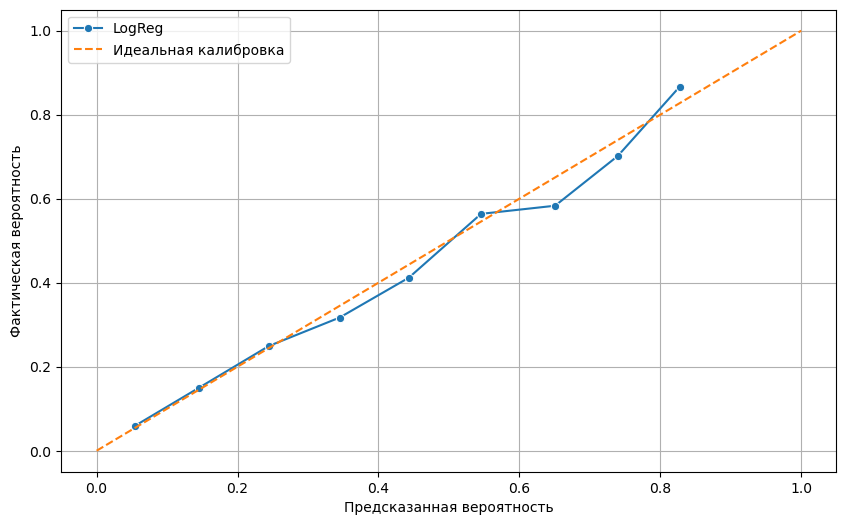

In [92]:
# вычисление точек диаграммы
prob_lr_true, prob_lr_pred = calibration_curve(
    y_test,
    y_lr_score,
    n_bins=10
)
# диаграмма калибровки для LogReg
sns.lineplot(x=prob_lr_pred, y=prob_lr_true, marker='o', label='LogReg')
# диаграмма идеально откалиброванной модели
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', label='Идеальная калибровка')
plt.xlabel("Предсказанная вероятность")
plt.ylabel("Фактическая вероятность")
plt.grid()
plt.show()

**Проверка калибровки LinearSVC**

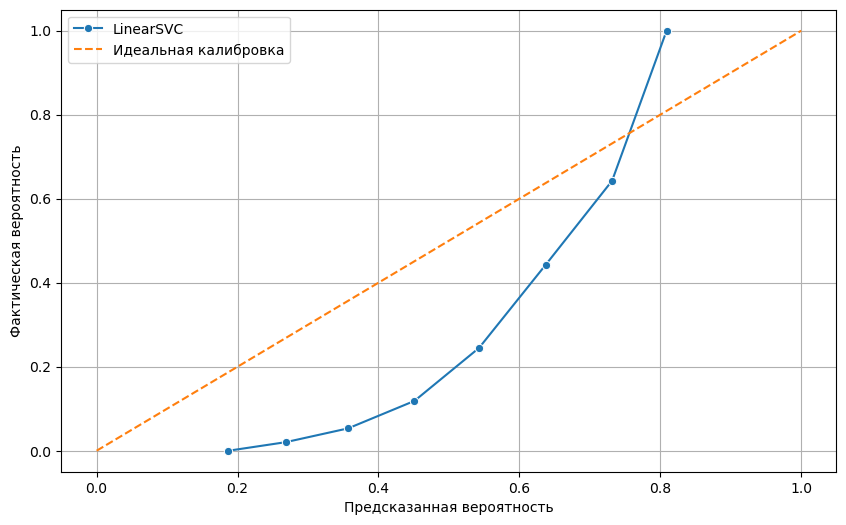

In [93]:
# вычисление точек диаграммы
prob_svc_true, prob_svc_pred = calibration_curve(
    y_test,
    y_svc_score_sigm,
    n_bins=10
)
# диаграмма калибровки для LinearSVC
sns.lineplot(x=prob_svc_pred, y=prob_svc_true, marker='o', label='LinearSVC')
# диаграмма идеально откалиброванной модели
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', label='Идеальная калибровка')
plt.xlabel("Предсказанная вероятность")
plt.ylabel("Фактическая вероятность")
plt.grid()
plt.show()

#### 9.2 Применение методов калибровки

Откалибруем модель LinearSVC как модель с высокой оценкой Бриера (плохой калибровкой по умолчанию). Для процедуры по заданию необходимо использовать отдельную калибровочную выборку. Выделим ее:

In [94]:
X_train_small, X_calib, y_train_small, y_calib = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y_train
)

In [95]:
svc_best.fit(X_train_small, y_train_small)
frozen = FrozenEstimator(svc_best)
# передаем предобученный эстиматор и запрещаем трогать его веса
calib_svc = CalibratedClassifierCV(estimator=frozen, method='isotonic', cv=cv)

In [96]:
calib_svc.fit(X_calib, y_calib)
# получение откалиброванных вероятностей
y_svc_score_calib = calib_svc.predict_proba(X_test)[:, 1]

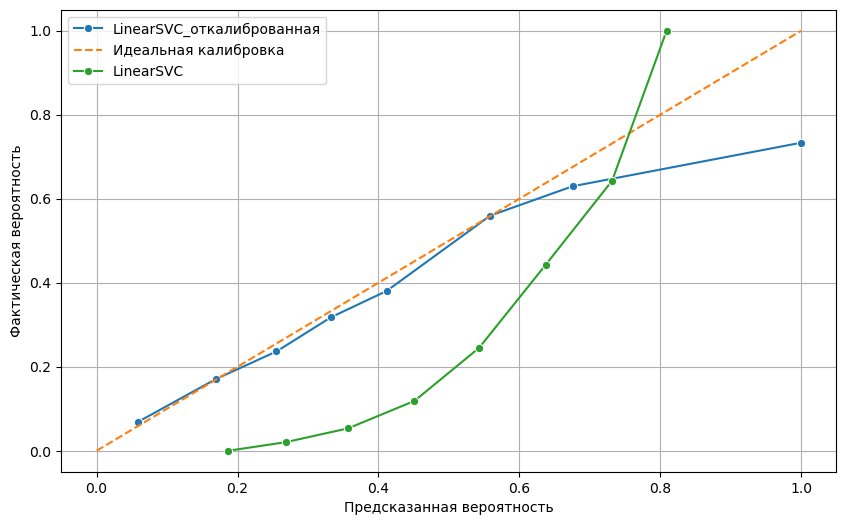

In [97]:
# вычисление точек диаграммы
prob_svc_calib_true, prob_svc_calib_pred = calibration_curve(
    y_test,
    y_svc_score_calib,
    n_bins=10
)
# диаграмма калибровки для откалиброванной LinearSVC
sns.lineplot(x=prob_svc_calib_pred, y=prob_svc_calib_true, marker='o', label='LinearSVC_откалиброванная')
# диаграмма идеально откалиброванной модели
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', label='Идеальная калибровка')
# диаграмма калибровки для LinearSVC
sns.lineplot(x=prob_svc_pred, y=prob_svc_true, marker='o', label='LinearSVC')
plt.xlabel("Предсказанная вероятность")
plt.ylabel("Фактическая вероятность")
plt.grid()
plt.show()

---
Наглядно видно, как сработал калибратор с кросс-валидацией. Откалиброванные вероятности устремились к идеальной диаграмме, пропала широкая область, где модель переоценивала вероятности.

#### 9.3 Сравнение моделей до и после калибровки

In [98]:
print("="*60)
print(f"Оценка Бриера для LinearSVC до калибровки {round(brier_score_loss(y_test, y_svc_score_sigm), 3)}")
print("="*60)
print(f"Оценка Бриера для LinearSVC после калибровки {round(brier_score_loss(y_test, y_svc_score_calib), 3)}")
print("="*60)

Оценка Бриера для LinearSVC до калибровки 0.215
Оценка Бриера для LinearSVC после калибровки 0.125


---
Оценка Бриера для LinearSVC после калибровки сравнялась с оценкой для хорошо откалиброванной модели LogisticRegression.

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

#### 10.1 Расчет метрик калибровки

Реализуем вспомогательную функцию расчета ECE и MCE

In [99]:
def calculate_ece_mce(y_true, y_prob, n_bins=10):
    """
    Рассчитывает ECE, MCE
    """
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    max_error = 0
    n = len(y_true)
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            ece += np.sum(mask) * np.abs(bin_conf - bin_acc)
            max_error = max(max_error, np.abs(bin_conf - bin_acc))
    return ece / n, max_error

#### 10.2 Сравнение моделей до и после калибровки

In [100]:
calib_metrics = pd.DataFrame({
    'Model': ['uncalibrated_LinearSVC', 'calibrated_LinearSVC', 'LogisticRegression'],
    'PR_AUC': [average_precision_score(y_test, y_svc_score_sigm), average_precision_score(y_test, y_svc_score_calib), average_precision_score(y_test, y_lr_score)],
    'Brier score': [brier_score_loss(y_test, y_svc_score_sigm), brier_score_loss(y_test, y_svc_score_calib), brier_score_loss(y_test, y_lr_score)],
    'ECE': [calculate_ece_mce(y_test, y_svc_score_sigm)[0], calculate_ece_mce(y_test, y_svc_score_calib)[0], calculate_ece_mce(y_test, y_lr_score)[0]],
    'MCE': [calculate_ece_mce(y_test, y_svc_score_sigm)[1], calculate_ece_mce(y_test, y_svc_score_calib)[1], calculate_ece_mce(y_test, y_lr_score)[1]]
})
calib_metrics[['PR_AUC', 'Brier score', 'ECE', 'MCE']] = calib_metrics[['PR_AUC', 'Brier score', 'ECE', 'MCE']].round(3)

print("="*60)
print("Сравнение моделей до и после калибровки")
print(calib_metrics)
print("="*60)

Сравнение моделей до и после калибровки
                    Model  PR_AUC  Brier score    ECE    MCE
0  uncalibrated_LinearSVC   0.398        0.215  0.296  0.332
1    calibrated_LinearSVC   0.382        0.125  0.011  0.267
2      LogisticRegression   0.399        0.125  0.009  0.067


---
Результат калибровки LinearSVC:
- Значение оценки Бриера после калибровки снизилось с 0.215 до 0.125, что говорит об улучшении качества вероятностей модели в целом.  
- Критически упало среднее расхождение вероятностей ECE, что опять же положительно характеризует качество прогнозируемых моделью вероятностей после калибровки.  
- Максимальная ошикба MCE снизилась незначительно: с 33.2% до 26.7%, так как осталась зона завышения вероятности относительно фактической. 


## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

#### 11.1 Сводная таблица результатов

In [101]:
# отдельно обучим Dummy не через кросс-валидацию, а напрямую
dummy_pipeline.fit(X_train, y_train)
y_dummy = dummy_pipeline.predict(X_test)

In [102]:
calib_metrics.loc[3] = {
    'Model': 'DummyClassifier',
    'PR_AUC': average_precision_score(y_test, y_dummy),
    'Brier score': brier_score_loss(y_test, y_dummy),
    'ECE': calculate_ece_mce(y_test, y_dummy)[0],
    'MCE': calculate_ece_mce(y_test, y_dummy)[0]
}
calib_metrics[['PR_AUC', 'Brier score', 'ECE', 'MCE']] = calib_metrics[['PR_AUC', 'Brier score', 'ECE', 'MCE']].round(3)

In [103]:
print("="*60)
print("Сравнение всех моделей")
print("="*60)
calib_metrics

Сравнение всех моделей


,Model,PR_AUC,Brier score,ECE,MCE
0,uncalibrated_LinearSVC,0.398,0.215,0.296,0.332
1,calibrated_LinearSVC,0.382,0.125,0.011,0.267
2,LogisticRegression,0.399,0.125,0.009,0.067
3,DummyClassifier,0.171,0.282,0.282,0.282


По результатам обоих классификаторов (LinearSVC, LogReg) получены следующие топ-5 важных признаков:

In [104]:
top_features = [item.replace('target__', '') for item in coef_comparison.head(5)['feature'].to_list()]
top_features = [item.replace('num__', '') for item in top_features]
print("="*60)
print("Самые важные по весам признаки")
print("="*60)
top_features

Самые важные по весам признаки


['app_id', 'site_id', 'device_model', 'ml_feature_9', 'ml_feature_10']

#### 11.2 Общие выводы

1) Качество моделей на тестовой выборке существенно улучшилось по сравнению с базовой моделью DummyClassifier. Метрика PR-AUC выросла с 0.171 (случайное угадывание с учётом баланса классов) до 0.399 в лучшем случае (LogReg).

2) Наибольший вклад в предсказание вероятности клика вносят:
    - app_id и site_id - идентификаторы рекламируемого приложения и веб-сайта показа. Это логично: конкретное приложение или сайт имеют кликабельность, которая переросла в хорошую связь при Таргет кодировании и получила высокий вес в моделях.
    - device_model - модель устройства пользователя. Тип устройства может влиять на поведение на сайте
    - ml_feature_9 и ml_feature_10 - машинно-сгенерированные признаки. Анонимны, но имеют и немалые веса, и коэффициенты корреляции с таргетом.

#### 11.3 Рекомендации

1. Создание признаков: к примеру site_category * device_type, app_id * hour. Это может добавить предсказательную силу для признаков, которые могли получить малый вес по отдельности
2. Из признака `hour` можно вычленить какие-либо временные метки и проанализировать связь с таргетом
3. Расширение методов калибровки (использование калибровки ПЛатта)

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.